# ECOSTRESS Processing Pipeline (Collection 2 / ECO_L2T_LSTE)

Steps covered in this notebook:
1. Download raw ECOSTRESS tiffs *(manual, via AppEEARS -- see note below)*
2. Parse Collection 2 tiled filenames
3. Apply QA/QC masking
4. Organize by temporal phase
5. Merge scenes <30 min apart
6. Calculate grid coverage

**Input:** a single folder containing ECOSTRESS `.tif`/`.tiff` files (any mix of `LST`, `QC`, `cloud`, `water`, `height`, `EmisWB`, `LST_err` bands). Any non-tiff files in the folder are skipped automatically.

**Output:** a new `Processed_Output` subfolder created inside the input folder, containing numbered subfolders for each processing stage, so nothing overwrites your raw downloads.


In [14]:
import os
import re
import glob
import shutil
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask
from shapely.geometry import box
import matplotlib.pyplot as plt


## Step 1: Download raw ECOSTRESS tiffs

This step is **manual** and happens outside this notebook, via AppEEARS (see the earlier walkthrough for submitting an Area request, uploading the ROI shapefile, and downloading the bundle).

This notebook assumes:
- All downloaded `.tif` files (across all bands and dates) are sitting in one flat folder, `INPUT_FOLDER`.
- Supporting files (README, QC lookup CSV, metadata XML, etc.) may also be in that folder -- they'll be skipped automatically since we only ever touch `.tif`/`.tiff` files.

Update the settings below to match your setup before running the rest of the notebook.


In [15]:
# ================== User Settings ==================

INPUT_FOLDER = r"/Users/ks/Desktop/Wu/LA_Tiffs"
# INPUT_FOLDER = r"/Users/ks/Desktop/Wu/Testing"


OUTPUT_ROOT     = os.path.join(INPUT_FOLDER, "01_Processed_Output")
QC_MASKED_DIR   = os.path.join(OUTPUT_ROOT, "01_QC_Masked")
COVERAGE_DIR    = os.path.join(OUTPUT_ROOT, "02_Grid_Coverage")
SEASONAL_DIR    = os.path.join(OUTPUT_ROOT, "03_Seasonal_Summary")   # NEW

for d in [OUTPUT_ROOT, QC_MASKED_DIR, COVERAGE_DIR, SEASONAL_DIR]:
    os.makedirs(d, exist_ok=True)

# ---- QC masking settings (see markdown above for rationale) ----
REQUIRE_PRODUCED_BY_TES = True
ACCEPTABLE_DATA_QUALITY_FLAGS = ["Good quality L1B data"]
ACCEPTABLE_LST_ACCURACY_LABELS = [
    "1 - 1.5 K (Good performance)",
    "1.5 - 2 K (Marginal performance)",
]
MASK_CLOUDS = True
MASK_WATER  = True
CLOUD_FLAG_VALUE = 0
WATER_FLAG_VALUE = 0

# ---- NEW: valid-pixel ratio filter ----
# Scenes with fewer than this fraction of valid (QC+cloud+water passed) pixels
# are excluded from all downstream steps (organize/merge/coverage), but are
# still logged in the valid_ratio_summary.csv report.
MIN_VALID_RATIO = 0.50

# ---- Temporal organization settings ----
MERGE_WINDOW_MIN = 5
LOCAL_TZ = "America/Los_Angeles"
HOUR_LABELS = [f"{h:02d}" for h in range(24)]     # NEW: hourly (diurnal) bins, replaces PHASE_CATEGORIES
SEASON_MONTHS = {                                  # NEW: meteorological seasons
    "Winter (DJF)": [12, 1, 2],
    "Spring (MAM)": [3, 4, 5],
    "Summer (JJA)": [6, 7, 8],
    "Fall (SON)":   [9, 10, 11],
}

# ---- Grid coverage settings ----
GRID_SHAPEFILE = r"Study_Region/LA/study_region.shp"
GRID_ID_FIELD = "GRID_ID"
COVERAGE_THRESHOLD = 0.50

# NOTE on resolution: ECOSTRESS L2T_LSTE is natively distributed at 70 m.
# 70 m keeps native resolution (best for freight-corridor variability);
# 100 m mildly aggregates for a smaller/faster grid. Pick one:

## Step 2: Parse Collection 2 tiled filenames

Collection 2 `ECO_L2T_LSTE` filenames look like:

```
ECO_L2T_LSTE.002_cloud_20180802T230140_aid0001_11N.tif
ECO_L2T_LSTE.002_LST_20180802T230140_aid0001_11N.tif
ECO_L2T_LSTE.002_QC_20180802T230140_aid0001_11N.tif
```

Each acquisition (one timestamp + tile) produces **one file per band** (`LST`, `LST_err`, `QC`, `cloud`, `water`, `height`, `EmisWB`). The functions below parse each filename and group same-acquisition band files together, so the QC/cloud files can be matched up with their corresponding LST file in the next step.

Any file that doesn't match this pattern (e.g. leftover README/CSV/metadata files, or `.tif` files that aren't ECOSTRESS output) is skipped with a printed note, rather than crashing the pipeline.


In [16]:
# Matches: ECO_L2T_LSTE.002_cloud_20180802T230140_aid0001_11N.tif
FILENAME_PATTERN = re.compile(
    r'^ECO_L2T_LSTE\.(?P<version>\d{3})_'
    r'(?P<band>LST_err|LST|QC|cloud|water|height|EmisWB)_'
    r'(?P<timestamp>\d{8}T\d{6})_'
    r'aid(?P<aid>\d+)_'
    r'(?P<utm_zone>\d{1,2}[A-Z])'
    r'\.tiff?$',
    re.IGNORECASE
)

BAND_NAMES = ["LST", "LST_err", "QC", "cloud", "water", "height", "EmisWB"]


def list_tiffs(folder_path):
    """Returns only .tif/.tiff files directly inside folder_path, skipping everything else."""
    if not os.path.isdir(folder_path):
        return []
    return [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith((".tif", ".tiff"))
    ]


def parse_ecostress_filename(path):
    """
    Parses an ECO_L2T_LSTE filename into its components.
    Returns a dict: {version, band, dt_utc, aid, utm_zone, path} or None if it doesn't match
    (e.g. a non-ECOSTRESS tiff, or a malformed name -- these are skipped, not errored on).
    """
    filename = os.path.basename(path)
    match = FILENAME_PATTERN.match(filename)
    if not match:
        print(f"  Skipping (doesn't match expected pattern): {filename}")
        return None

    try:
        dt_utc = datetime.strptime(match.group("timestamp"), "%Y%m%dT%H%M%S").replace(
            tzinfo=ZoneInfo("UTC")
        )
    except ValueError:
        print(f"  Skipping (bad timestamp): {filename}")
        return None

    return {
        "version": match.group("version"),
        "band": match.group("band"),
        "dt_utc": dt_utc,
        "aid": match.group("aid"),
        "utm_zone": match.group("utm_zone"),
        "path": path,
    }


def group_files_by_acquisition(folder_path):
    """
    Groups all band tiffs directly inside folder_path by acquisition
    (same timestamp + aid + utm_zone). Non-tiff files and non-matching
    tiffs are skipped automatically.

    Returns: {(timestamp_str, aid, utm_zone): {band_name: filepath, ...}}
    """
    groups = {}
    for fpath in list_tiffs(folder_path):
        parsed = parse_ecostress_filename(fpath)
        if parsed is None:
            continue
        key = (parsed["dt_utc"].strftime("%Y%m%dT%H%M%S"), parsed["aid"], parsed["utm_zone"])
        groups.setdefault(key, {})[parsed["band"]] = fpath
    return groups


# quick preview of what's in the input folder
print(f"Scanning {INPUT_FOLDER} ...")
acquisitions = group_files_by_acquisition(INPUT_FOLDER)
print(f"\nFound {len(acquisitions)} acquisition(s)")
print("Done")


Scanning /Users/ks/Desktop/Wu/LA_Tiffs ...

Found 2241 acquisition(s)
Done


## Step 3: Apply QA/QC masking

For each acquisition, this step:
1. Reads the `QC` band and keeps only pixels whose QC value is in `ACCEPTABLE_QC_VALUES`.
2. Optionally applies the `cloud` mask (drops pixels not equal to `CLOUD_FLAG_VALUE`).
3. Optionally applies the `water` mask (drops pixels not equal to `WATER_FLAG_VALUE`), if you want to exclude water surfaces.
4. Writes out a QC-masked `LST` tiff (masked pixels become `NaN`) into `01_QC_Masked/`.

Acquisitions missing an `LST` or `QC` band are skipped (printed as a warning) since masking isn't possible without both.

**Before trusting this in production:** open the `ECO-L2T-LSTE-002-QC-lookup.csv` and `ECO-L2T-LSTE-002-cloud-lookup.csv` files from your AppEEARS supporting-files download and confirm `ACCEPTABLE_QC_VALUES` / `CLOUD_FLAG_VALUE` / `WATER_FLAG_VALUE` above actually match "good quality" / "clear" / "not water" in those tables -- the defaults here are placeholders.


Loaded QC lookup: 209 total QC values, 66 acceptable QC values selected.

=== QC Masking Summary ===
Acquisitions scanned       : 2241
Files written              : 549
Mean swath footprint       : 45.8%
Mean valid pixel ratio     : 36.9%
Passed threshold           : 549/2241 (24.5%)
Report saved               : /Users/ks/Desktop/Wu/LA_Tiffs/01_Processed_Output/valid_ratio_summary.csv


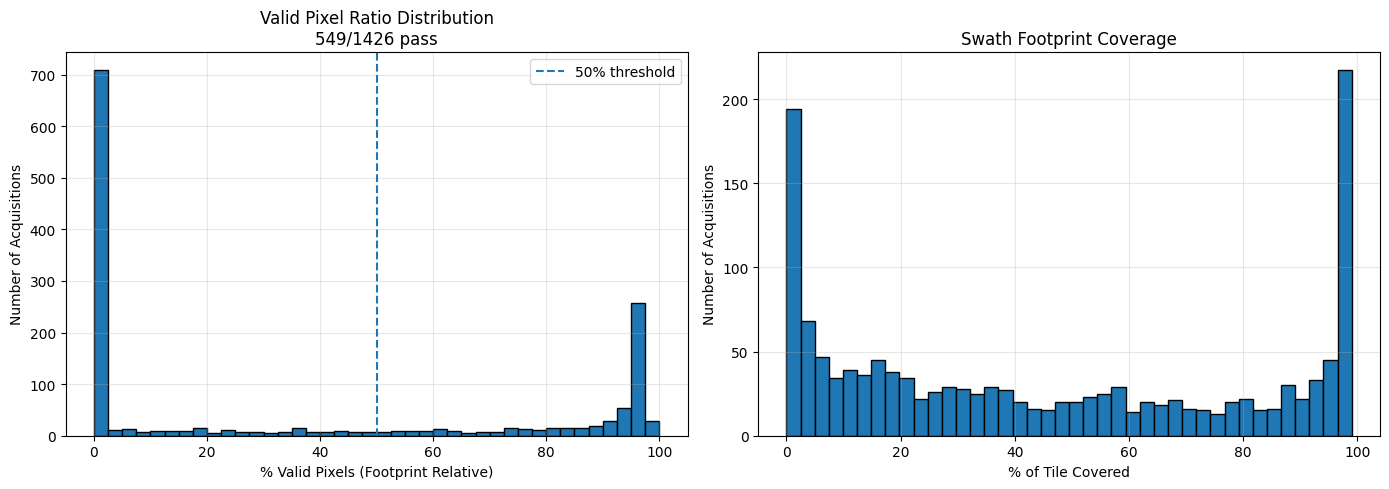


=== Diagnostic Summary ===
Median footprint coverage : 39.1%
Median valid ratio        : 3.7%
Diagnostic plot saved     : /Users/ks/Desktop/Wu/LA_Tiffs/01_Processed_Output/valid_ratio_diagnostics.png


,timestamp_utc,aid,utm_zone,n_tile_pixels,n_footprint,n_valid,valid_ratio,passed_threshold,written
0,20180802T230140,0001,11N,1487522,638872,597718,0.935583,True,True
1,20180802T230232,0001,11N,1487522,849020,809908,0.953933,True,True
2,20180805T052542,0001,11N,0,0,0,NaN,False,False
3,20180805T220222,0001,11N,1071610,699,584,0.835479,True,True
4,20180805T220314,0001,11N,1487522,18951,18213,0.961057,True,True
...,...,...,...,...,...,...,...,...,...
2236,20250721T224948,0001,11N,1487522,1241001,999898,0.805719,True,True
2237,20250724T220125,0001,11N,1487522,1249174,1068219,0.855140,True,True
2238,20250725T211311,0001,11N,1487522,723541,692937,0.957702,True,True
2239,20250728T202407,0001,11N,1487522,1447222,1247156,0.861759,True,True


In [17]:
QC_LOOKUP_CSV = "ECO-L2T-LSTE-002-QC-lookup.csv"   # expected in the same directory as this notebook

# Which categories count as "acceptable"
REQUIRE_PRODUCED_BY_TES = True

ACCEPTABLE_DATA_QUALITY_FLAGS = ["Good quality L1B data"]

ACCEPTABLE_LST_ACCURACY_LABELS = [
    "1 - 1.5 K (Good performance)",
    "1.5 - 2 K (Marginal performance)",
]


def load_acceptable_qc_values(qc_lookup_path,
                              require_produced_by_tes=REQUIRE_PRODUCED_BY_TES,
                              acceptable_data_quality_flags=ACCEPTABLE_DATA_QUALITY_FLAGS,
                              acceptable_lst_accuracy_labels=ACCEPTABLE_LST_ACCURACY_LABELS):
    """
    Reads the ECO-L2T-LSTE QC lookup CSV and returns acceptable QC pixel values.
    """
    if not os.path.isfile(qc_lookup_path):
        raise FileNotFoundError(
            f"QC lookup CSV not found: {qc_lookup_path}\n"
            f"Make sure {os.path.basename(qc_lookup_path)} is in the same directory as this notebook."
        )

    qc_lookup = pd.read_csv(qc_lookup_path)

    mask = pd.Series(True, index=qc_lookup.index)

    if require_produced_by_tes:
        mask &= qc_lookup["Mandatory QA flags"].str.startswith(
            "Pixel produced by TES", na=False
        )

    mask &= qc_lookup["Data quality flag"].isin(acceptable_data_quality_flags)
    mask &= qc_lookup["LST accuracy"].isin(acceptable_lst_accuracy_labels)

    acceptable_values = set(qc_lookup.loc[mask, "Value"].astype(int))

    print(
        f"Loaded QC lookup: {len(qc_lookup)} total QC values, "
        f"{len(acceptable_values)} acceptable QC values selected."
    )

    return acceptable_values



def apply_qc_mask(band_files,
                  acceptable_qc_values,
                  mask_clouds,
                  mask_water,
                  cloud_flag_value,
                  water_flag_value,
                  out_path,
                  min_valid_ratio=MIN_VALID_RATIO):
    """
    Applies QC masking and writes masked LST only if valid pixel ratio threshold is met.
    """

    if "LST" not in band_files or "QC" not in band_files:
        return {
            "n_tile_pixels": 0,
            "n_footprint": 0,
            "n_valid": 0,
            "valid_ratio": np.nan,
            "passed_threshold": False,
            "written": False
        }

    with rasterio.open(band_files["LST"]) as lst_src:
        lst = lst_src.read(1).astype("float32")

        if lst_src.nodata is not None and not np.isnan(lst_src.nodata):
            lst = np.where(lst == lst_src.nodata, np.nan, lst)

        meta = lst_src.meta.copy()

    with rasterio.open(band_files["QC"]) as qc_src:
        qc = qc_src.read(1)


    footprint_mask = np.isfinite(lst)

    n_tile_pixels = int(lst.size)
    n_footprint = int(footprint_mask.sum())

    good_mask = footprint_mask & np.isin(qc, list(acceptable_qc_values))


    if mask_clouds and "cloud" in band_files:
        with rasterio.open(band_files["cloud"]) as cloud_src:
            cloud = cloud_src.read(1)

        good_mask &= (cloud == cloud_flag_value)


    if mask_water and "water" in band_files:
        with rasterio.open(band_files["water"]) as water_src:
            water = water_src.read(1)

        good_mask &= (water == water_flag_value)


    lst_masked = np.where(good_mask, lst, np.nan)

    n_valid = int(np.isfinite(lst_masked).sum())

    valid_ratio = (
        n_valid / n_footprint
        if n_footprint
        else 0.0
    )

    passed = valid_ratio >= min_valid_ratio


    result = {
        "n_tile_pixels": n_tile_pixels,
        "n_footprint": n_footprint,
        "n_valid": n_valid,
        "valid_ratio": valid_ratio,
        "passed_threshold": passed,
        "written": False
    }


    if not passed:
        return result


    meta.update({
        "dtype": "float32",
        "nodata": np.nan
    })

    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(lst_masked, 1)


    result["written"] = True

    return result



def run_qc_masking(acquisitions,
                   out_dir,
                   qc_lookup_path=QC_LOOKUP_CSV,
                   min_valid_ratio=MIN_VALID_RATIO):

    acceptable_qc_values = load_acceptable_qc_values(qc_lookup_path)

    report_rows = []
    written = 0


    for (ts, aid, utm_zone), band_files in sorted(acquisitions.items()):

        out_name = (
            f"ECO_L2T_LSTE_{ts}_aid{aid}_{utm_zone}_LST_qcmasked.tif"
        )

        out_path = os.path.join(out_dir, out_name)


        result = apply_qc_mask(
            band_files,
            acceptable_qc_values,
            MASK_CLOUDS,
            MASK_WATER,
            CLOUD_FLAG_VALUE,
            WATER_FLAG_VALUE,
            out_path,
            min_valid_ratio
        )


        if result["written"]:
            written += 1


        report_rows.append({
            "timestamp_utc": ts,
            "aid": aid,
            "utm_zone": utm_zone,
            "n_tile_pixels": result["n_tile_pixels"],
            "n_footprint": result["n_footprint"],
            "n_valid": result["n_valid"],
            "valid_ratio": result["valid_ratio"],
            "passed_threshold": result["passed_threshold"],
            "written": result["written"],
        })


    report_df = (
        pd.DataFrame(report_rows)
        .sort_values("timestamp_utc")
    )


    report_path = os.path.join(
        OUTPUT_ROOT,
        "valid_ratio_summary.csv"
    )

    report_df.to_csv(report_path, index=False)


    n_scenes = len(report_df)
    n_passed = int(report_df["passed_threshold"].sum())

    mean_ratio = (
        report_df["valid_ratio"].mean()
        if n_scenes else np.nan
    )

    mean_footprint_pct = (
        (report_df["n_footprint"] /
         report_df["n_tile_pixels"]).mean() * 100
        if n_scenes else np.nan
    )


    print("\n=== QC Masking Summary ===")
    print(f"Acquisitions scanned       : {n_scenes}")
    print(f"Files written              : {written}")
    print(f"Mean swath footprint       : {mean_footprint_pct:.1f}%")
    print(f"Mean valid pixel ratio     : {mean_ratio*100:.1f}%")
    print(
        f"Passed threshold           : {n_passed}/{n_scenes} "
        f"({100*n_passed/n_scenes:.1f}%)"
    )
    print(f"Report saved               : {report_path}")


    return report_df



def plot_valid_ratio_diagnostics(report_df,
                                 out_dir,
                                 threshold=MIN_VALID_RATIO):

    df = report_df.dropna(subset=["valid_ratio"]).copy()

    if df.empty:
        return None


    df["footprint_pct"] = (
        100 *
        df["n_footprint"] /
        df["n_tile_pixels"].replace(0, np.nan)
    )


    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14,5)
    )


    axes[0].hist(
        df["valid_ratio"] * 100,
        bins=40,
        edgecolor="black"
    )

    axes[0].axvline(
        threshold * 100,
        linestyle="--",
        linewidth=1.5,
        label=f"{int(threshold*100)}% threshold"
    )

    n_passed = int(
        (df["valid_ratio"] >= threshold).sum()
    )

    axes[0].set_title(
        f"Valid Pixel Ratio Distribution\n"
        f"{n_passed}/{len(df)} pass"
    )

    axes[0].set_xlabel(
        "% Valid Pixels (Footprint Relative)"
    )

    axes[0].set_ylabel(
        "Number of Acquisitions"
    )

    axes[0].legend()
    axes[0].grid(True, alpha=0.3)



    axes[1].hist(
        df["footprint_pct"],
        bins=40,
        edgecolor="black"
    )

    axes[1].set_title(
        "Swath Footprint Coverage"
    )

    axes[1].set_xlabel(
        "% of Tile Covered"
    )

    axes[1].set_ylabel(
        "Number of Acquisitions"
    )

    axes[1].grid(True, alpha=0.3)


    plt.tight_layout()


    out_path = os.path.join(
        out_dir,
        "valid_ratio_diagnostics.png"
    )

    fig.savefig(
        out_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()


    print("\n=== Diagnostic Summary ===")
    print(
        f"Median footprint coverage : "
        f"{df['footprint_pct'].median():.1f}%"
    )

    print(
        f"Median valid ratio        : "
        f"{df['valid_ratio'].median()*100:.1f}%"
    )

    print(f"Diagnostic plot saved     : {out_path}")


    return out_path



qc_report = run_qc_masking(
    acquisitions,
    QC_MASKED_DIR
)

plot_valid_ratio_diagnostics(
    qc_report,
    OUTPUT_ROOT,
    threshold=MIN_VALID_RATIO
)

qc_report

## Step 4: Organize by temporal phase

Each QC-masked LST file's UTC timestamp is converted to local time (`LOCAL_TZ`) and classified into a phase:

- **Night**: 12am-5am
- **Morning**: 5am-12pm
- **Afternoon**: 12pm-5pm
- **Evening**: 5pm-12am

Files are copied (not moved -- the QC-masked originals stay in `01_QC_Masked/`) into `02_Organized_By_Phase/<Phase>/`.


Hour 00:00: 20 file(s)
Hour 01:00: 25 file(s)
Hour 02:00: 20 file(s)
Hour 03:00: 12 file(s)
Hour 04:00: 18 file(s)
Hour 05:00: 20 file(s)
Hour 06:00: 19 file(s)
Hour 07:00: 23 file(s)
Hour 08:00: 24 file(s)
Hour 09:00: 20 file(s)
Hour 10:00: 33 file(s)
Hour 11:00: 26 file(s)
Hour 12:00: 25 file(s)
Hour 13:00: 31 file(s)
Hour 14:00: 34 file(s)
Hour 15:00: 29 file(s)
Hour 16:00: 24 file(s)
Hour 17:00: 24 file(s)
Hour 18:00: 19 file(s)
Hour 19:00: 14 file(s)
Hour 20:00: 23 file(s)
Hour 21:00: 18 file(s)
Hour 22:00: 21 file(s)
Hour 23:00: 27 file(s)


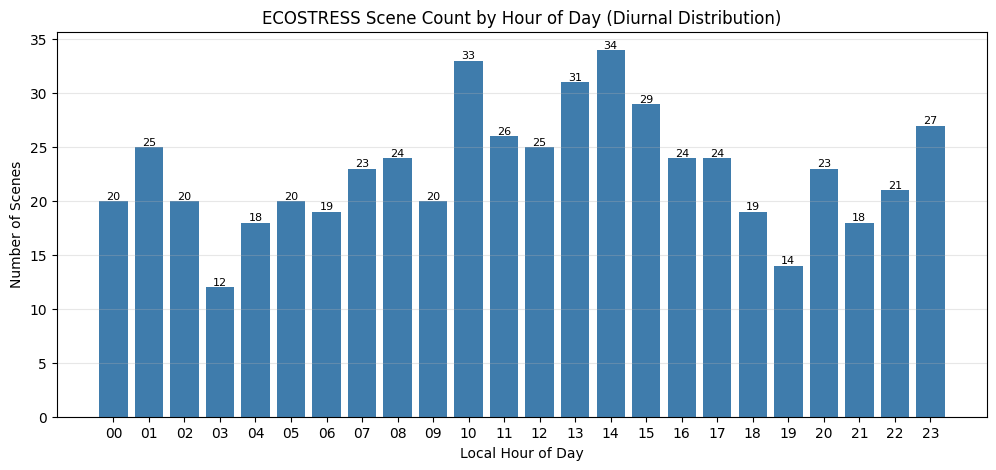


Saved -> /Users/ks/Desktop/Wu/LA_Tiffs/01_Processed_Output/01_QC_Masked/hour_counts.png


'/Users/ks/Desktop/Wu/LA_Tiffs/01_Processed_Output/01_QC_Masked/hour_counts.png'

In [18]:
def classify_season(month):
    for season, months in SEASON_MONTHS.items():
        if month in months:
            return season
    return "Unknown"


QC_MASKED_PATTERN = re.compile(
    r'^ECO_L2T_LSTE_(?P<timestamp>\d{8}T\d{6})_aid(?P<aid>\d+)_(?P<utm_zone>\d{1,2}[A-Z])_LST_qcmasked\.tiff?$',
    re.IGNORECASE
)


def parse_qc_masked_filename(path):
    filename = os.path.basename(path)
    match = QC_MASKED_PATTERN.match(filename)
    if not match:
        # print(f"  Skipping (doesn't match expected QC-masked pattern): {filename}")
        return None
    try:
        dt_utc = datetime.strptime(match.group("timestamp"), "%Y%m%dT%H%M%S").replace(tzinfo=ZoneInfo("UTC"))
    except ValueError:
        print(f"  Skipping (bad timestamp): {filename}")
        return None
    return {"dt_utc": dt_utc, "aid": match.group("aid"), "utm_zone": match.group("utm_zone"), "path": path}


def organize_by_hour(qc_masked_dir, local_tz=LOCAL_TZ):
    """
    Creates Hour_00 ... Hour_23 subfolders (local time) and moves each QC-masked
    tiff into the matching one, tagging it with its season. Replaces the old
    4-bin Night/Morning/Afternoon/Evening split now that data volume supports
    true diurnal (hourly) resolution.
    """
    for h in HOUR_LABELS:
        os.makedirs(os.path.join(qc_masked_dir, f"Hour_{h}"), exist_ok=True)

    classified = {h: [] for h in HOUR_LABELS}

    for fpath in list_tiffs(qc_masked_dir):
        parsed = parse_qc_masked_filename(fpath)
        if parsed is None:
            continue

        dt_local = parsed["dt_utc"].astimezone(ZoneInfo(local_tz))
        hour_label = f"{dt_local.hour:02d}"
        season = classify_season(dt_local.month)

        dest_path = os.path.join(qc_masked_dir, f"Hour_{hour_label}", os.path.basename(fpath))
        shutil.move(fpath, dest_path)
        classified[hour_label].append((dt_local, season, dest_path))

    return classified


def plot_hour_counts(classified, out_dir):
    """Bar plot of scene count per local hour-of-day (diurnal distribution)."""
    counts = [len(classified[h]) for h in HOUR_LABELS]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(HOUR_LABELS, counts, color="#3f7cac")
    for i, count in enumerate(counts):
        if count:
            ax.text(i, count, str(count), ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Local Hour of Day")
    ax.set_ylabel("Number of Scenes")
    ax.set_title("ECOSTRESS Scene Count by Hour of Day (Diurnal Distribution)")
    ax.grid(True, axis="y", alpha=0.3)

    out_path = os.path.join(out_dir, "hour_counts.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved -> {out_path}")
    return out_path


classified = organize_by_hour(QC_MASKED_DIR)

for h in HOUR_LABELS:
    entries = classified[h]
    if entries:
        print(f"Hour {h}:00: {len(entries)} file(s)")
        # for dt_local, season, path in sorted(entries):
        #     print(f"  {dt_local.strftime('%Y-%m-%d %H:%M:%S %Z')}  [{season}]  -> {os.path.basename(path)}")

plot_hour_counts(classified, QC_MASKED_DIR)

## Step 5: Merge scenes <5 min apart

Within each phase folder, consecutive scenes captured less than `MERGE_WINDOW_MIN` minutes apart are mosaicked together (mean of overlapping pixels), since they likely represent the same pass split across adjacent tiles/orbits. Merged outputs are saved to `02_Organized_By_Phase/<Phase>/merged/`.

Scenes with no close neighbor are left as single files (nothing to merge).


In [19]:
def mosaic_mean(files, out_path):
    """Mosaic a list of GeoTIFFs using the mean for overlapping pixels."""
    if len(files) == 0:
        return

    datasets = [rasterio.open(f) for f in files]
    ref = datasets[0]
    ref_crs = ref.crs

    xres, yres = ref.res
    xres, yres = abs(xres), abs(yres)

    minxs, maxxs, minys, maxys = [], [], [], []
    for ds in datasets:
        if ds.crs != ref_crs:
            raise ValueError("All rasters must have the same CRS.")
        b = ds.bounds
        minxs.append(min(b.left, b.right))
        maxxs.append(max(b.left, b.right))
        minys.append(min(b.bottom, b.top))
        maxys.append(max(b.bottom, b.top))

    minx, maxx = min(minxs), max(maxxs)
    miny, maxy = min(minys), max(maxys)

    width = int(np.ceil((maxx - minx) / xres))
    height = int(np.ceil((maxy - miny) / yres))
    mosaic_transform = from_bounds(minx, miny, maxx, maxy, width, height)

    n = len(datasets)
    stack = np.full((n, height, width), np.nan, dtype="float32")

    for i, ds in enumerate(datasets):
        data = ds.read(1).astype("float32")
        if ds.nodata is not None and not np.isnan(ds.nodata):
            data = np.where(data == ds.nodata, np.nan, data)

        dest = np.full((height, width), np.nan, dtype="float32")
        reproject(
            source=data,
            destination=dest,
            src_transform=ds.transform,
            src_crs=ds.crs,
            dst_transform=mosaic_transform,
            dst_crs=ref_crs,
            src_nodata=None,
            dst_nodata=np.nan,
            resampling=Resampling.nearest,
        )
        stack[i] = dest

    mosaic_arr = np.nanmean(stack, axis=0).astype("float32")

    meta = ref.meta.copy()
    meta.update({"height": height, "width": width, "transform": mosaic_transform,
                 "dtype": "float32", "nodata": np.nan})

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mosaic_arr, 1)

    for ds in datasets:
        ds.close()


def group_by_time(entries, max_minutes=MERGE_WINDOW_MIN):
    """entries: list of (dt_local, path), already sorted or not."""
    max_delta = timedelta(minutes=max_minutes)
    items = sorted(entries, key=lambda x: x[0])

    groups = []
    current_group = []
    for dt_local, path in items:
        if not current_group:
            current_group = [(dt_local, path)]
            continue
        prev_dt = current_group[-1][0]
        if dt_local - prev_dt <= max_delta:
            current_group.append((dt_local, path))
        else:
            groups.append(current_group)
            current_group = [(dt_local, path)]
    if current_group:
        groups.append(current_group)
    return groups


def run_merging(qc_masked_dir, merge_window_min=MERGE_WINDOW_MIN):
    """Merges scenes <merge_window_min apart within each Hour_XX subfolder."""
    for h in HOUR_LABELS:
        hour_folder = os.path.join(qc_masked_dir, f"Hour_{h}")
        files = list_tiffs(hour_folder)
        if not files:
            continue

        entries = []
        for f in files:
            parsed = parse_qc_masked_filename(f)
            if parsed is None:
                continue
            dt_local = parsed["dt_utc"].astimezone(ZoneInfo(LOCAL_TZ))
            entries.append((dt_local, f))

        groups = group_by_time(entries, max_minutes=merge_window_min)
        print(f"\n[Hour {h}:00] {len(groups)} merge group(s) from {len(entries)} file(s)")

        merged_folder = os.path.join(hour_folder, "merged")

        for i, group in enumerate(groups, start=1):
            if len(group) == 1:
                continue

            group_files = [p for _, p in group]
            dts = [dt for dt, _ in group]
            first_dt, last_dt = min(dts), max(dts)
            ts1, ts2 = first_dt.strftime("%Y%m%dT%H%M%S"), last_dt.strftime("%Y%m%dT%H%M%S")
            out_name = f"Hour{h}_group{i:03d}_{ts1}_to_{ts2}_mean.tif"
            out_path = os.path.join(merged_folder, out_name)

            # print(f"  Merging {len(group_files)} file(s) -> {out_name}")
            # for f in group_files:
            #     print(f"    {os.path.basename(f)}")

            mosaic_mean(group_files, out_path)

    print("\nMerging done.")


run_merging(QC_MASKED_DIR, merge_window_min=MERGE_WINDOW_MIN)


[Hour 00:00] 18 merge group(s) from 20 file(s)


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")



[Hour 01:00] 24 merge group(s) from 25 file(s)

[Hour 02:00] 16 merge group(s) from 20 file(s)


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty sli


[Hour 03:00] 10 merge group(s) from 12 file(s)


...

/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")



[Hour 21:00] 18 merge group(s) from 18 file(s)

[Hour 22:00] 19 merge group(s) from 21 file(s)


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")



[Hour 23:00] 23 merge group(s) from 27 file(s)

Merging done.


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1393426648.py:52: RuntimeWarning: Mean of empty slice
  mosaic_arr = np.nanmean(stack, axis=0).astype("float32")


## Step 6: Calculate grid coverage

For every processed tiff (both merged files and any single unmerged scenes), this computes the fraction of valid (non-NaN, QC-passed) pixels inside each grid cell of your study grid, and flags a cell as "covered" if that fraction exceeds `COVERAGE_THRESHOLD`.

Outputs to `04_Grid_Coverage/`:
- `grid_coverage_summary.csv` -- one row per tiff, with `% grid cells covered`
- one PNG per tiff showing which cells are covered (red) vs. not (white)


Found existing grid -> /Users/ks/Desktop/Wu/LA_Tiffs/SoLA_70m_grid/SoLA_70m_grid.shp (647681 cells). Skipping generation.
Saved comparison plot -> /Users/ks/Desktop/Wu/LA_Tiffs/01_Processed_Output/02_Grid_Coverage/03_boundary_vs_grid_comparison.png


Computing grid coverage:   0%|          | 0/613 [00:00<?, ?tiff/s]

/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/2751810409.py:196: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/2751810409.py:196: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/2751810409.py:196: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/2751810409.py:196: UserWarning: The GeoDataFrame you are attempting t

KeyboardInterrupt: 

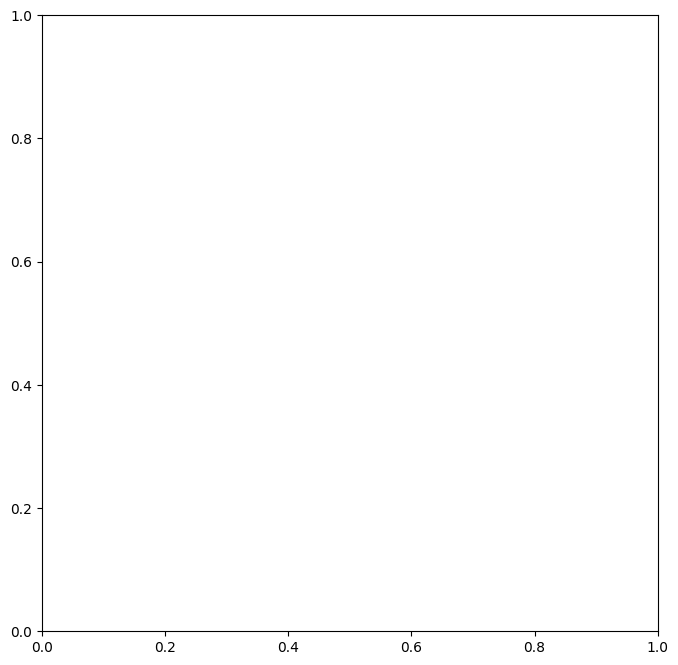

In [20]:
from tqdm.notebook import tqdm

# ================== Grid Generation Settings ==================
STUDY_REGION_SHAPEFILE = r"Study_Region/LA/study_region.shp"   # path to the SoLA study region outline (just the boundary polygon)
GRID_CELL_SIZE_M = 70                                    # grid cell size in meters (1000 = 1 km x 1 km)
CLIP_GRID_TO_BOUNDARY = True                                # if True, cells at the edge are clipped to the outline (partial cells); if False, full square cells are kept as long as they intersect the outline

GRID_DIR = os.path.join(COVERAGE_DIR, "01_SOLA_Grid")
SUMMARY_DIR = os.path.join(COVERAGE_DIR, "02_Summary")

# grid lives directly under the input folder, e.g. .../Testing/SoLA_70m_grid/SoLA_70m_grid.shp
GRID_NAME = f"SoLA_{GRID_CELL_SIZE_M}m_grid"
GENERATED_GRID_SHP = os.path.join(INPUT_FOLDER, GRID_NAME, f"{GRID_NAME}.shp")

import shapely  # top-level shapely 2.0 vectorized functions (box, intersects, contains, intersection)
from rasterio.features import rasterize  # for the vectorized coverage step below


def build_grid_from_boundary(boundary_shp, cell_size_m=GRID_CELL_SIZE_M,
                              grid_id_field=GRID_ID_FIELD, clip_to_boundary=CLIP_GRID_TO_BOUNDARY,
                              out_grid_path=None):
    """
    Reads a study region outline shapefile and generates a regular square grid
    (cell_size_m x cell_size_m) covering it.

    Vectorized: builds all candidate cells at once (no per-cell Python loop),
    does one vectorized intersects() test against the boundary, then only runs
    the expensive intersection()/clip on cells that actually straddle the edge
    -- fully-interior cells (the majority at fine resolution) are kept as-is.

    Returns a GeoDataFrame with columns [grid_id_field, geometry], in the same
    CRS the grid was built in (a projected/metric CRS, auto-estimated from the
    boundary if it isn't already projected).
    """
    if not os.path.isfile(boundary_shp):
        raise FileNotFoundError(f"Study region shapefile not found: {boundary_shp}")

    boundary_gdf = gpd.read_file(boundary_shp)

    if boundary_gdf.crs is None:
        raise ValueError("Study region shapefile has no CRS defined -- fix the .prj before proceeding.")

    if boundary_gdf.crs.is_geographic:
        projected_crs = boundary_gdf.estimate_utm_crs()
        boundary_gdf = boundary_gdf.to_crs(projected_crs)
    else:
        projected_crs = boundary_gdf.crs

    boundary_union = boundary_gdf.geometry.union_all()
    minx, miny, maxx, maxy = boundary_union.bounds

    x_edges = np.arange(minx, maxx + cell_size_m, cell_size_m)
    y_edges = np.arange(miny, maxy + cell_size_m, cell_size_m)

    xx, yy = np.meshgrid(x_edges[:-1], y_edges[:-1])
    xmin_flat, ymin_flat = xx.ravel(), yy.ravel()
    xmax_flat, ymax_flat = xmin_flat + cell_size_m, ymin_flat + cell_size_m

    all_cells = shapely.box(xmin_flat, ymin_flat, xmax_flat, ymax_flat)  # vectorized (shapely >= 2.0)
    intersects_mask = shapely.intersects(all_cells, boundary_union)
    candidate_cells = all_cells[intersects_mask]

    if clip_to_boundary:
        # Only cells that AREN'T fully inside the boundary need clipping -- at fine
        # resolution most candidate cells are fully interior.
        fully_inside_mask = shapely.contains(boundary_union, candidate_cells)
        interior_cells = candidate_cells[fully_inside_mask]
        edge_cells = candidate_cells[~fully_inside_mask]

        if len(edge_cells):
            clipped_edge_cells = shapely.intersection(edge_cells, boundary_union)
            clipped_edge_cells = clipped_edge_cells[~shapely.is_empty(clipped_edge_cells)]
        else:
            clipped_edge_cells = np.array([], dtype=object)

        final_cells = np.concatenate([interior_cells, clipped_edge_cells])
    else:
        final_cells = candidate_cells

    grid_gdf = gpd.GeoDataFrame(
        {grid_id_field: range(1, len(final_cells) + 1)},
        geometry=final_cells,
        crs=projected_crs,
    )

    print(f"Generated {len(grid_gdf)} grid cell(s) ({cell_size_m}m x {cell_size_m}m) covering the study region.")

    if out_grid_path:
        os.makedirs(os.path.dirname(out_grid_path), exist_ok=True)
        grid_gdf.to_file(out_grid_path)
        print(f"Saved grid -> {out_grid_path}")

    return grid_gdf, boundary_gdf


def load_or_build_grid(existing_grid_path, boundary_shp, cell_size_m=GRID_CELL_SIZE_M,
                        grid_id_field=GRID_ID_FIELD, clip_to_boundary=CLIP_GRID_TO_BOUNDARY):
    """
    Looks for an existing grid shapefile first (e.g. SoLA_70m_grid/SoLA_70m_grid.shp).
    If found, loads it directly instead of regenerating. If missing, asks the user
    whether to build a new one or stop the pipeline.
    """
    if os.path.isfile(existing_grid_path):
        grid_gdf = gpd.read_file(existing_grid_path)
        boundary_gdf = gpd.read_file(boundary_shp)
        if boundary_gdf.crs != grid_gdf.crs:
            boundary_gdf = boundary_gdf.to_crs(grid_gdf.crs)
        print(f"Found existing grid -> {existing_grid_path} ({len(grid_gdf)} cells). Skipping generation.")
        return grid_gdf, boundary_gdf

    response = input(
        f"No existing grid found at:\n  {existing_grid_path}\n"
        f"Create a new {cell_size_m}m grid now? [y/n]: "
    ).strip().lower()

    if response != "y":
        raise SystemExit("Pipeline stopped -- no grid available.")

    return build_grid_from_boundary(
        boundary_shp, cell_size_m=cell_size_m, grid_id_field=grid_id_field,
        clip_to_boundary=clip_to_boundary, out_grid_path=existing_grid_path,
    )


def plot_boundary_vs_grid(boundary_gdf, grid_gdf, out_dir):
    """Saves a side-by-side PNG: study region outline vs. generated grid.
    This is the ONE file that stays directly in out_dir (COVERAGE_DIR), not in a subfolder."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    boundary_gdf.plot(ax=axes[0], color="lightblue", edgecolor="black", linewidth=1)
    axes[0].set_title("Study Region Outline (SoLA)")
    axes[0].axis("off")

    grid_gdf.plot(ax=axes[1], facecolor="none", edgecolor="black", linewidth=0.3)
    boundary_gdf.boundary.plot(ax=axes[1], color="red", linewidth=1.5)
    axes[1].set_title(f"Generated {GRID_CELL_SIZE_M}m Grid ({len(grid_gdf)} cells) over Outline")
    axes[1].axis("off")

    out_path = os.path.join(out_dir, "03_boundary_vs_grid_comparison.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved comparison plot -> {out_path}")
    return out_path


def find_all_processed_tiffs(qc_masked_dir):
    """Finds every tiff under qc_masked_dir (QC-masked phase files + merged subfolders)."""
    tiff_paths = []
    for dirpath, dirnames, filenames in os.walk(qc_masked_dir):
        for fname in filenames:
            if fname.lower().endswith((".tif", ".tiff")):
                tiff_paths.append(os.path.join(dirpath, fname))
    return sorted(tiff_paths)


def compute_grid_coverage(grid_orig, raster_path, threshold=COVERAGE_THRESHOLD):
    """
    Vectorized: rasterizes all grid cell IDs onto the raster's pixel grid ONCE,
    then uses np.bincount to get valid/total pixel counts for every cell in a
    single pass -- avoids one separate raster read/clip per grid cell.
    """
    grid = grid_orig.reset_index(drop=True).copy()
    n_cells = len(grid)

    with rasterio.open(raster_path) as src:
        grid_work = grid.to_crs(src.crs)
        data = src.read(1).astype("float32")
        if src.nodata is not None and not np.isnan(src.nodata):
            data = np.where(data == src.nodata, np.nan, data)

        shapes = ((geom, i + 1) for i, geom in enumerate(grid_work.geometry))
        cell_id_arr = rasterize(
            shapes, out_shape=data.shape, transform=src.transform,
            fill=0, dtype="int32", all_touched=False,
        )

        valid_mask = np.isfinite(data)

        total_counts = np.bincount(cell_id_arr.ravel(), minlength=n_cells + 1)
        valid_counts = np.bincount(cell_id_arr[valid_mask].ravel(), minlength=n_cells + 1)

    total_counts = total_counts[1:n_cells + 1]
    valid_counts = valid_counts[1:n_cells + 1]

    with np.errstate(divide="ignore", invalid="ignore"):
        valid_frac = np.where(total_counts > 0, valid_counts / total_counts, 0.0)

    grid["valid_fraction"] = valid_frac
    grid["covered"] = grid["valid_fraction"] > threshold
    return grid


def plot_grid_coverage(grid_with_coverage, tiff_name, out_dir, threshold=COVERAGE_THRESHOLD):
    fig, ax = plt.subplots(figsize=(8, 8))
    grid_with_coverage[~grid_with_coverage["covered"]].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
    grid_with_coverage[grid_with_coverage["covered"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.2)
    pct_covered = 100 * grid_with_coverage["covered"].mean()
    ax.set_title(f"{tiff_name}\nGrid cells covered (>{int(threshold*100)}%): {pct_covered:.1f}%")
    ax.axis("off")
    out_path = os.path.join(out_dir, f"{tiff_name}_coverage.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path


def run_grid_coverage(qc_masked_dir, grid_gdf, grid_id_field, coverage_dir, summary_dir, threshold=COVERAGE_THRESHOLD):
    """
    Computes grid coverage for every tiff under qc_masked_dir, and saves each
    coverage PNG into coverage_dir mirroring the same Hour/merged folder
    structure the source tiff was found in (e.g. Hour_14/, Hour_09/merged/).
    The combined summary CSV goes into summary_dir, not coverage_dir directly.
    """
    files = find_all_processed_tiffs(qc_masked_dir)
    if not files:
        print("No processed tiffs found -- did steps 3-5 run successfully?")
        return pd.DataFrame()

    summary_rows = []
    for f in tqdm(files, desc="Computing grid coverage", unit="tiff"):
        rel_path = os.path.relpath(f, qc_masked_dir)
        rel_dir = os.path.dirname(rel_path)
        tiff_name = os.path.splitext(os.path.basename(f))[0]

        grid_cov = compute_grid_coverage(grid_gdf, f, threshold=threshold)
        n_total = len(grid_cov)
        n_covered = int(grid_cov["covered"].sum())
        pct_covered = 100 * n_covered / n_total if n_total else 0.0

        summary_rows.append({
            "tiff_file": rel_path,
            "n_grid_cells": n_total,
            "n_covered": n_covered,
            "pct_covered": pct_covered,
        })

        out_subdir = os.path.join(coverage_dir, rel_dir) if rel_dir else coverage_dir
        os.makedirs(out_subdir, exist_ok=True)
        plot_grid_coverage(grid_cov, tiff_name, out_subdir, threshold=threshold)

    summary_df = pd.DataFrame(summary_rows)
    os.makedirs(summary_dir, exist_ok=True)
    summary_csv_path = os.path.join(summary_dir, "grid_coverage_summary.csv")
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Saved summary -> {summary_csv_path}")

    return summary_df


grid_gdf, boundary_gdf = load_or_build_grid(
    GENERATED_GRID_SHP, STUDY_REGION_SHAPEFILE, cell_size_m=GRID_CELL_SIZE_M,
    grid_id_field=GRID_ID_FIELD, clip_to_boundary=CLIP_GRID_TO_BOUNDARY,
)
plot_boundary_vs_grid(boundary_gdf, grid_gdf, COVERAGE_DIR)

coverage_summary = run_grid_coverage(
    QC_MASKED_DIR, grid_gdf, GRID_ID_FIELD, COVERAGE_DIR, SUMMARY_DIR, threshold=COVERAGE_THRESHOLD
)
coverage_summary

/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/4283953735.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


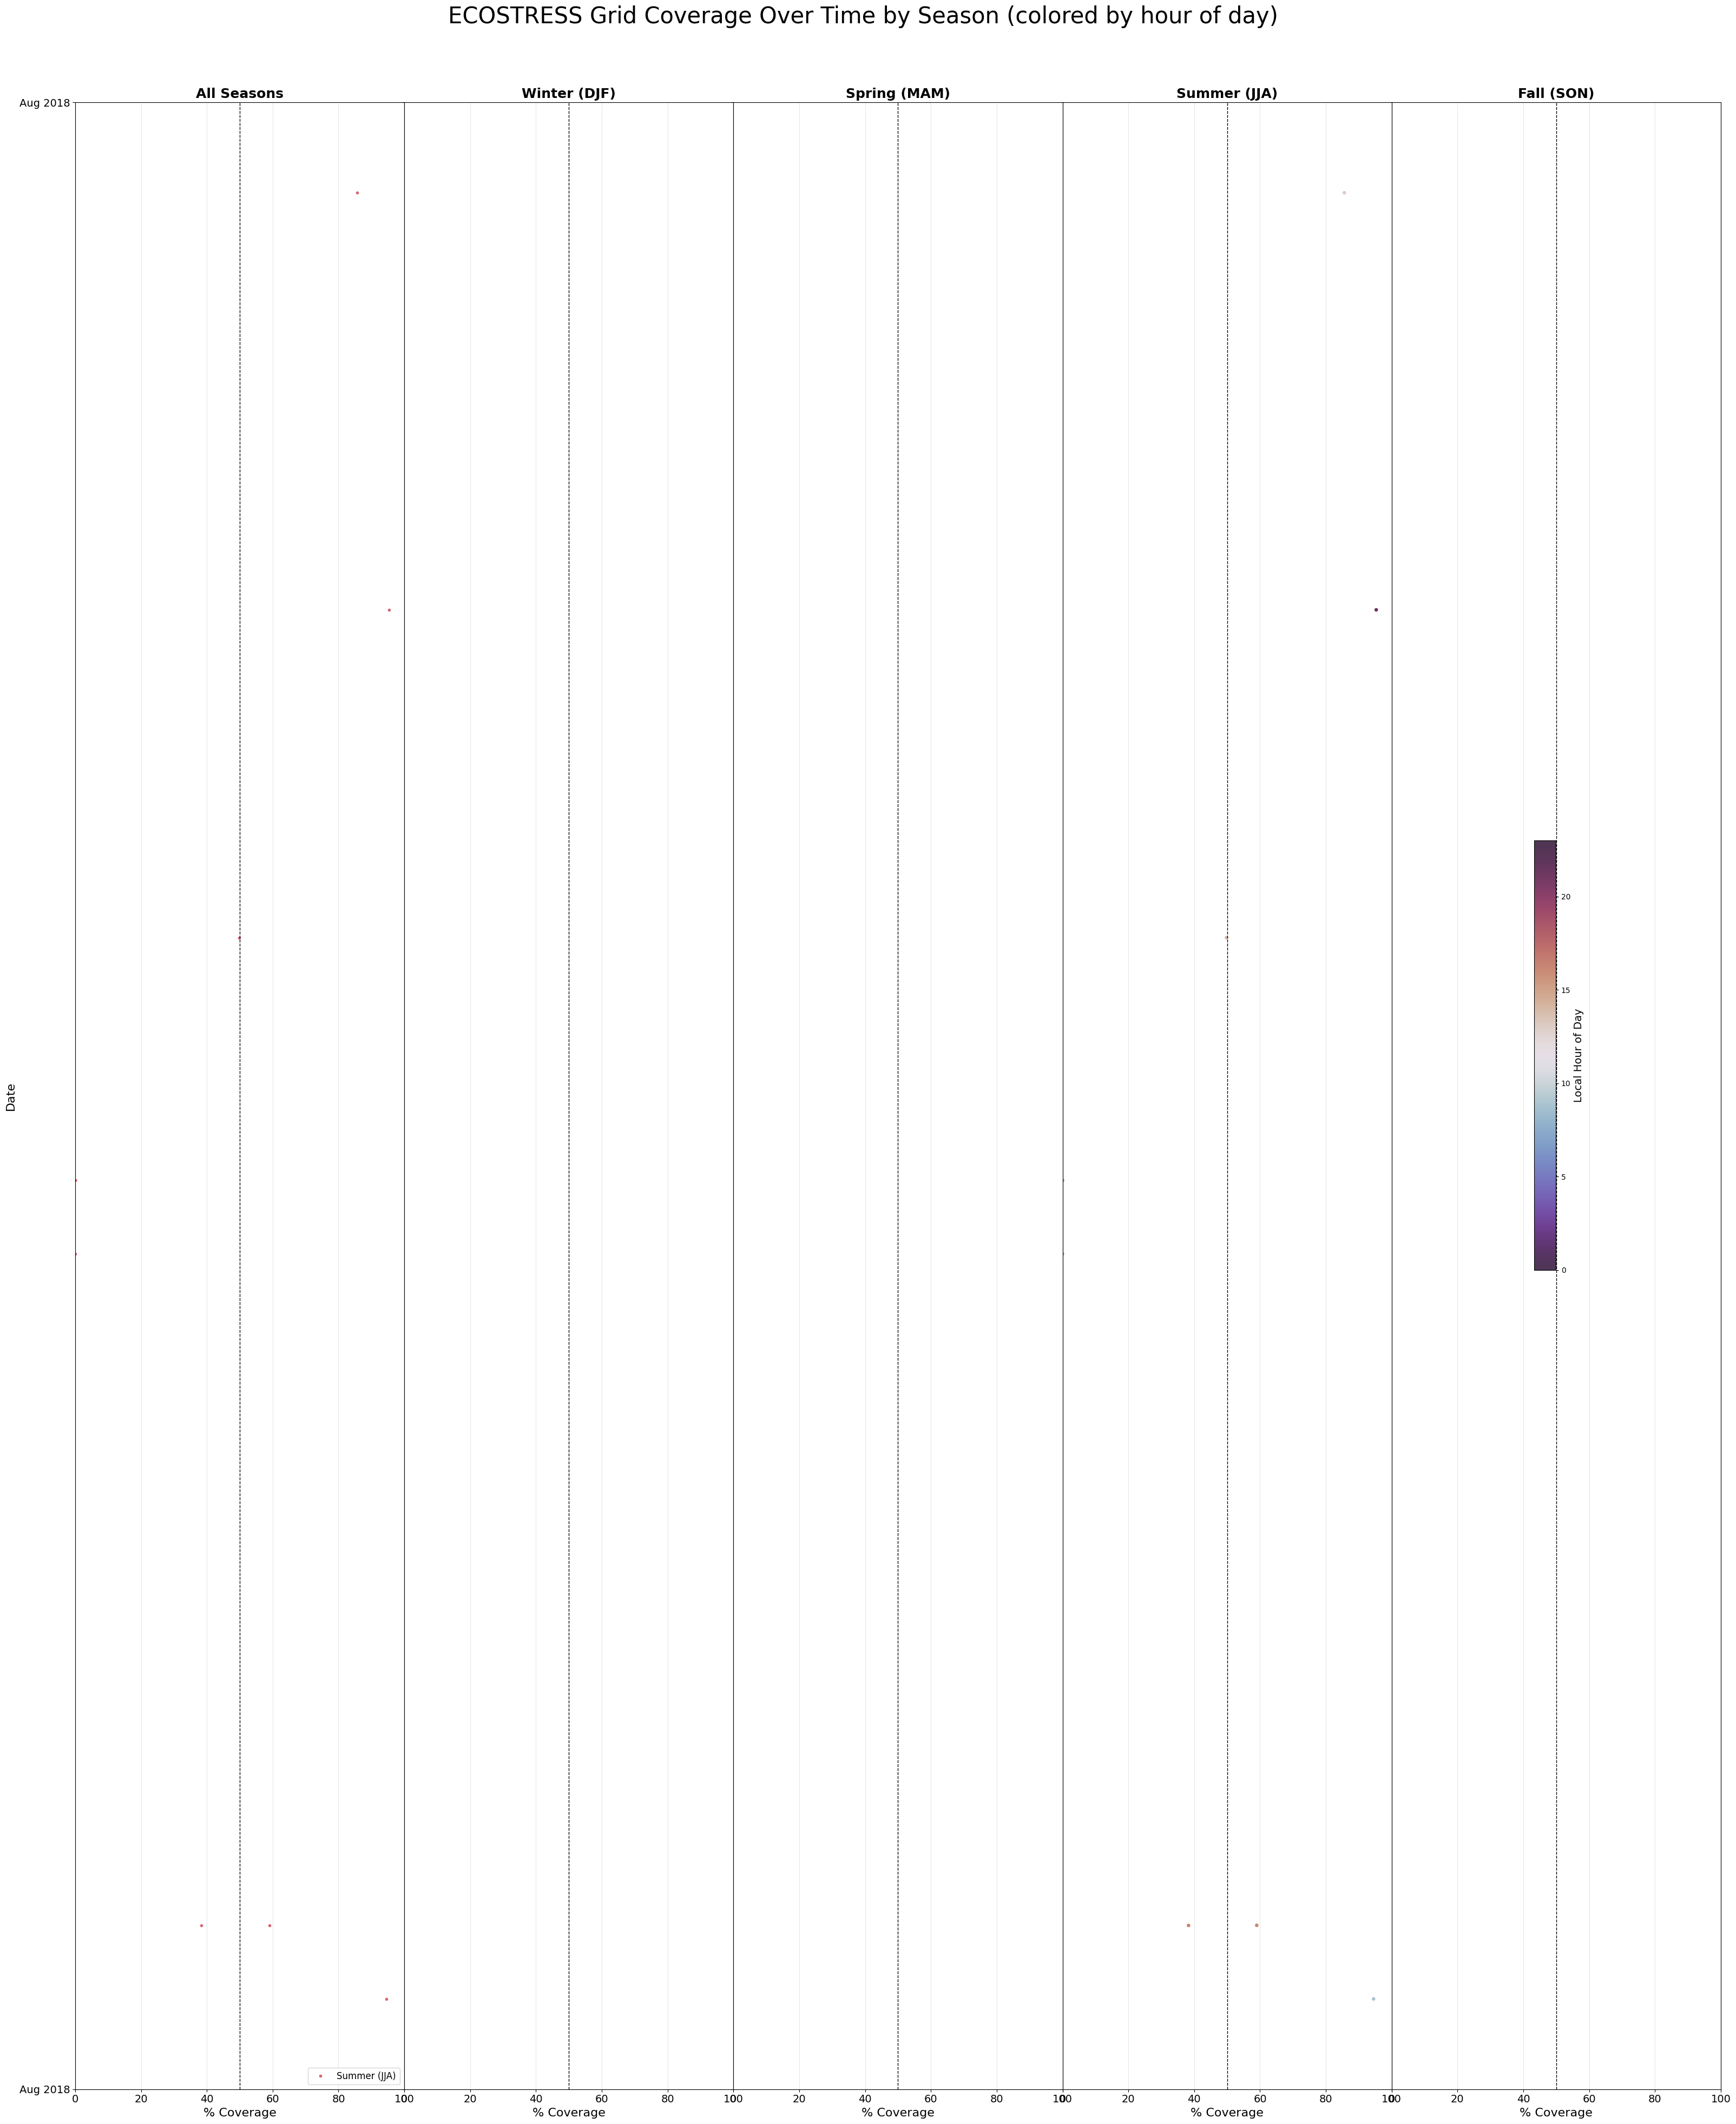

Saved -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/coverage_over_time.png

5 tiff(s) below the 50% threshold:
                                                                 tiff_file                  datetime  pct_covered
         Hour_16/ECO_L2T_LSTE_20180802T230140_aid0001_11N_LST_qcmasked.tif 2018-08-02 16:01:40-07:00    38.271927
Hour_15/merged/Hour15_group001_20180805T150222_to_20180805T150314_mean.tif 2018-08-05 08:02:22-07:00     0.000000
         Hour_15/ECO_L2T_LSTE_20180805T220222_aid0001_11N_LST_qcmasked.tif 2018-08-05 15:02:22-07:00     0.000000
         Hour_15/ECO_L2T_LSTE_20180805T220314_aid0001_11N_LST_qcmasked.tif 2018-08-05 15:03:14-07:00     0.000000
         Hour_14/ECO_L2T_LSTE_20180806T211046_aid0001_11N_LST_qcmasked.tif 2018-08-06 14:10:46-07:00    49.831630


'/Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/coverage_over_time.png'

In [11]:
# ================== Coverage Over Time Plot (Side-by-Side) ==================

import matplotlib.dates as mdates
import matplotlib.colors as mcolors

SEASON_COLORS = {
    "Winter (DJF)": "#2c3e88",
    "Spring (MAM)": "#4caf50",
    "Summer (JJA)": "#d1495b",
    "Fall (SON)":   "#e8a33d",
}
SEASON_ORDER = ["Winter (DJF)", "Spring (MAM)", "Summer (JJA)", "Fall (SON)"]

TIMESTAMP_IN_PATH_PATTERN = re.compile(r'(\d{8}T\d{6})')


def extract_datetime_from_tiff_file(rel_path, local_tz=LOCAL_TZ):
    """Returns (datetime_local, hour_label, season) parsed from the filename timestamp."""
    filename = os.path.basename(rel_path)
    match = TIMESTAMP_IN_PATH_PATTERN.search(filename)
    if not match:
        return None, None, None

    dt_utc = datetime.strptime(match.group(1), "%Y%m%dT%H%M%S").replace(tzinfo=ZoneInfo("UTC"))
    dt_local = dt_utc.astimezone(ZoneInfo(local_tz))
    return dt_local, f"{dt_local.hour:02d}", classify_season(dt_local.month)


def plot_coverage_over_time(coverage_summary_df, out_dir, threshold=COVERAGE_THRESHOLD):
    df = coverage_summary_df.copy()

    parsed = df["tiff_file"].apply(extract_datetime_from_tiff_file)
    df["datetime"] = parsed.apply(lambda x: x[0])
    df["hour"] = parsed.apply(lambda x: int(x[1]) if x[1] is not None else None)
    df["season"] = parsed.apply(lambda x: x[2])

    n_unparsed = df["datetime"].isna().sum()
    if n_unparsed:
        print(f"Warning: could not parse {n_unparsed} timestamp(s).")

    df = df.dropna(subset=["datetime"]).sort_values("datetime")

    if df.empty:
        print("No valid timestamps found.")
        return None

    # cyclical colormap for hour-of-day (0 = midnight ... 23 = 11pm)
    hour_cmap = plt.get_cmap("twilight_shifted")
    hour_norm = mcolors.Normalize(vmin=0, vmax=23)

    fig, axes = plt.subplots(1, 5, figsize=(32, 40), sharey=True, gridspec_kw={"wspace": 0})

    # ==========================================================
    # Plot 1: All seasons overview (colored by season)
    # ==========================================================
    ax = axes[0]
    for season in SEASON_ORDER:
        season_df = df[df["season"] == season]
        if season_df.empty:
            continue
        ax.plot(
            season_df["pct_covered"], season_df["datetime"],
            marker="o", markersize=3, linewidth=0, alpha=0.8,
            color=SEASON_COLORS.get(season, "gray"), label=season,
        )
    ax.axvline(threshold * 100, color="black", linestyle="--", linewidth=1)
    ax.set_title("All Seasons", fontsize=18, fontweight="bold")
    ax.set_xlabel("% Coverage", fontsize=16)
    ax.set_ylabel("Date", fontsize=16)
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc="lower right")

    # ==========================================================
    # Plots 2-5: one per season, points colored by local hour-of-day
    # ==========================================================
    sc = None
    for ax, season in zip(axes[1:], SEASON_ORDER):
        season_df = df[df["season"] == season]
        if not season_df.empty:
            sc = ax.scatter(
                season_df["pct_covered"], season_df["datetime"],
                c=season_df["hour"], cmap=hour_cmap, norm=hour_norm,
                s=14, alpha=0.85,
            )
        ax.axvline(threshold * 100, color="black", linestyle="--", linewidth=1)
        ax.set_title(season, fontsize=18, fontweight="bold")
        ax.set_xlabel("% Coverage", fontsize=16)
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)

    if sc is not None:
        cbar = fig.colorbar(sc, ax=axes[1:], orientation="vertical", fraction=0.02, pad=0.02)
        cbar.set_label("Local Hour of Day", fontsize=14)

    # ==========================================================
    # Format date axis
    # ==========================================================
    locator = mdates.MonthLocator(interval=3)
    formatter = mdates.DateFormatter("%b %Y")
    for ax in axes:
        ax.yaxis.set_major_locator(locator)
        ax.yaxis.set_major_formatter(formatter)
        ax.tick_params(axis="both", which="major", labelsize=14)

    fig.suptitle("ECOSTRESS Grid Coverage Over Time by Season (colored by hour of day)", fontsize=30, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    out_path = os.path.join(out_dir, "coverage_over_time.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    # ==========================================================
    # Print low coverage scenes
    # ==========================================================
    low_coverage = df[df["pct_covered"] < threshold * 100]
    if not low_coverage.empty:
        print(f"\n{len(low_coverage)} tiff(s) below the {int(threshold*100)}% threshold:")
        print(low_coverage[["tiff_file", "datetime", "pct_covered"]].to_string(index=False))

    return out_path


plot_coverage_over_time(coverage_summary, SUMMARY_DIR, threshold=COVERAGE_THRESHOLD)

/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1253690700.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["datetime"].dt.to_period("M").astype(str)


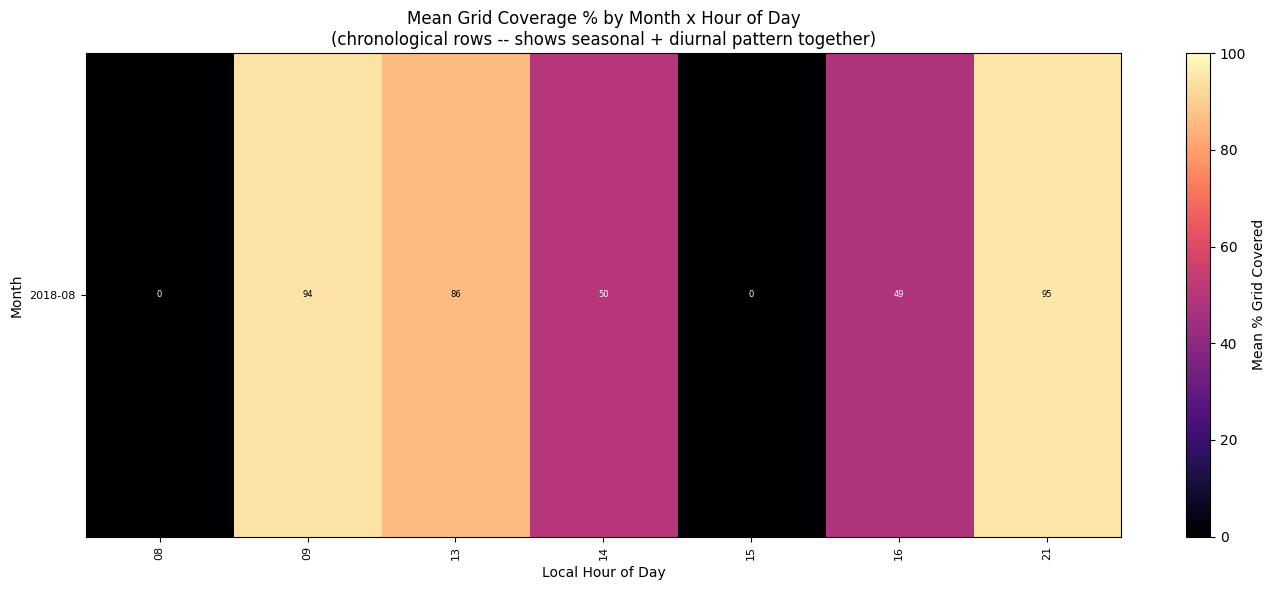

Saved -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/coverage_calendar_heatmap.png


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_1505/1253690700.py:55: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df["datetime"].dt.to_period("M")).agg(


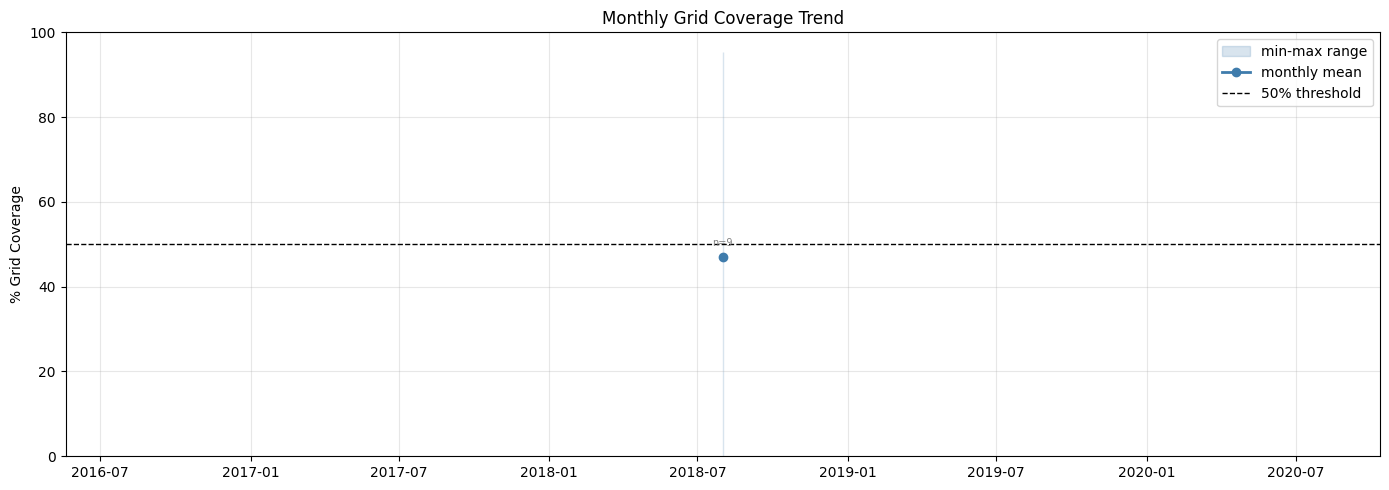

Saved -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/coverage_monthly_trend.png


'/Users/ks/Desktop/Wu/Testing/01_Processed_Output/02_Grid_Coverage/02_Summary/coverage_monthly_trend.png'

In [12]:
def build_calendar_hour_pivot(coverage_summary_df, local_tz=LOCAL_TZ):
    """
    Aggregates per-scene coverage into a (calendar month) x (local hour) grid.
    Chronological month labels (e.g. '2019-06') preserve trend-over-time, while
    the hour axis still shows diurnal pattern -- both in a single readable plot.
    """
    df = coverage_summary_df.copy()
    parsed = df["tiff_file"].apply(lambda p: extract_datetime_from_tiff_file(p, local_tz))
    df["datetime"] = parsed.apply(lambda x: x[0])
    df["hour"] = parsed.apply(lambda x: x[1])
    df = df.dropna(subset=["datetime"])

    df["year_month"] = df["datetime"].dt.to_period("M").astype(str)

    pivot = df.pivot_table(index="year_month", columns="hour", values="pct_covered", aggfunc="mean").sort_index()
    counts = df.pivot_table(index="year_month", columns="hour", values="pct_covered", aggfunc="count").reindex(pivot.index)

    return df, pivot, counts


def plot_coverage_calendar_heatmap(pivot, counts, out_dir, threshold=COVERAGE_THRESHOLD):
    fig, ax = plt.subplots(figsize=(14, max(6, 0.35 * len(pivot))))
    im = ax.imshow(pivot.values, aspect="auto", cmap="magma", vmin=0, vmax=100)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=8, rotation=90)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xlabel("Local Hour of Day")
    ax.set_ylabel("Month")
    ax.set_title("Mean Grid Coverage % by Month x Hour of Day\n(chronological rows -- shows seasonal + diurnal pattern together)")

    # only annotate cells that actually have data; skip empty months/hours (no acquisitions)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isnan(val):
                continue
            color = "white" if val < 60 else "black"
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6, color=color)

    fig.colorbar(im, ax=ax, label="Mean % Grid Covered")
    plt.tight_layout()

    out_path = os.path.join(out_dir, "coverage_calendar_heatmap.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")
    return out_path


def plot_monthly_coverage_trend(df, out_dir, threshold=COVERAGE_THRESHOLD):
    """Monthly mean trend with a min-max shaded band -- much easier to read the
    overall trajectory than a scatter cloud of every individual scene."""
    monthly = df.groupby(df["datetime"].dt.to_period("M")).agg(
        mean_cov=("pct_covered", "mean"),
        min_cov=("pct_covered", "min"),
        max_cov=("pct_covered", "max"),
        n=("pct_covered", "count"),
    )
    monthly.index = monthly.index.to_timestamp()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(monthly.index, monthly["min_cov"], monthly["max_cov"],
                     color="#3f7cac", alpha=0.2, label="min-max range")
    ax.plot(monthly.index, monthly["mean_cov"], color="#3f7cac", marker="o",
            linewidth=2, label="monthly mean")
    ax.axhline(threshold * 100, color="black", linestyle="--", linewidth=1,
               label=f"{int(threshold*100)}% threshold")

    for x, y, n in zip(monthly.index, monthly["mean_cov"], monthly["n"]):
        ax.annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(0, 8),
                    fontsize=7, ha="center", color="gray")

    ax.set_ylabel("% Grid Coverage")
    ax.set_title("Monthly Grid Coverage Trend")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    out_path = os.path.join(out_dir, "coverage_monthly_trend.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")
    return out_path


cal_df, cal_pivot, cal_counts = build_calendar_hour_pivot(coverage_summary)
plot_coverage_calendar_heatmap(cal_pivot, cal_counts, SUMMARY_DIR, threshold=COVERAGE_THRESHOLD)
plot_monthly_coverage_trend(cal_df, SUMMARY_DIR, threshold=COVERAGE_THRESHOLD)

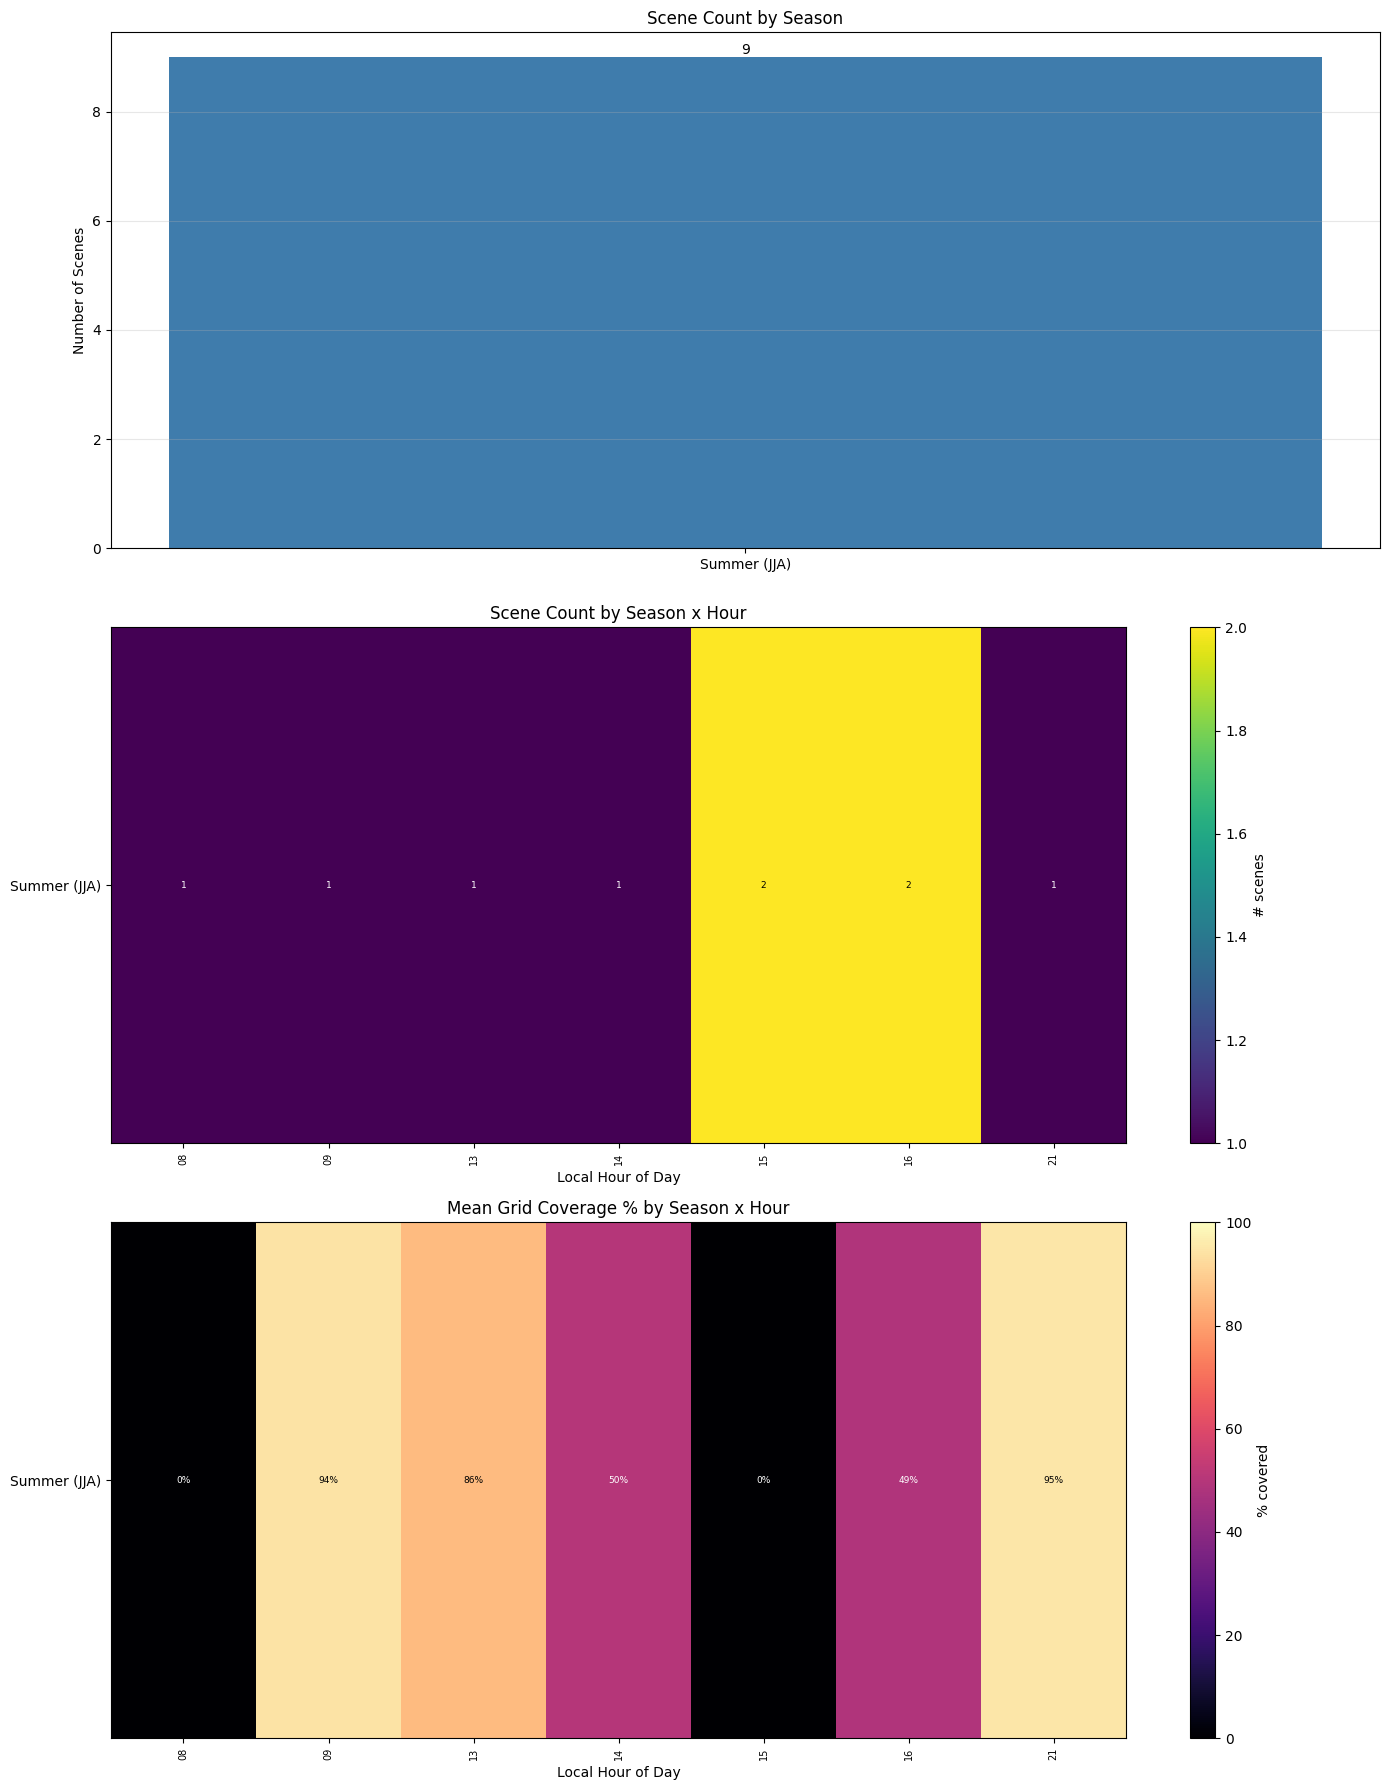

Saved -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/03_Seasonal_Summary/seasonal_diurnal_summary.png
Saved seasonal report -> /Users/ks/Desktop/Wu/Testing/01_Processed_Output/03_Seasonal_Summary/seasonal_summary_report.txt


'/Users/ks/Desktop/Wu/Testing/01_Processed_Output/03_Seasonal_Summary/seasonal_summary_report.txt'

In [13]:
# ================== Step 7: Seasonal & Diurnal Summary ==================
def build_seasonal_diurnal_summary(coverage_summary_df, local_tz=LOCAL_TZ):
    df = coverage_summary_df.copy()
    parsed = df["tiff_file"].apply(lambda p: extract_datetime_from_tiff_file(p, local_tz))
    df["datetime"] = parsed.apply(lambda x: x[0])
    df["hour"] = parsed.apply(lambda x: x[1])
    df["season"] = parsed.apply(lambda x: x[2])
    df = df.dropna(subset=["datetime"])

    season_counts = df.groupby("season").size().rename("n_scenes").reset_index()
    pivot_counts = df.pivot_table(index="season", columns="hour", values="tiff_file",
                                   aggfunc="count", fill_value=0)
    pivot_coverage = df.pivot_table(index="season", columns="hour", values="pct_covered", aggfunc="mean")

    return df, season_counts, pivot_counts, pivot_coverage


def _annotate_heatmap(ax, data, fmt="{:.0f}", cmap_name="viridis", vmin=None, vmax=None):
    """Writes the numeric value into each heatmap cell, flipping text color for contrast."""
    vmin = np.nanmin(data) if vmin is None else vmin
    vmax = np.nanmax(data) if vmax is None else vmax
    span = (vmax - vmin) or 1
    cmap = plt.get_cmap(cmap_name)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                continue
            norm_val = (val - vmin) / span
            text_color = "white" if norm_val < 0.6 else "black"
            ax.text(j, i, fmt.format(val), ha="center", va="center",
                     fontsize=6.5, color=text_color)


def plot_seasonal_summary(season_counts, pivot_counts, pivot_coverage, out_dir):
    # 3 rows, 1 column now (was 1 row, 3 columns)
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))

    # ---- Row 1: scene count by season (bar chart with counts on top) ----
    ax0 = axes[0]
    bars = ax0.bar(season_counts["season"], season_counts["n_scenes"], color="#3f7cac")
    for bar, count in zip(bars, season_counts["n_scenes"]):
        ax0.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(count)),
                  ha="center", va="bottom", fontsize=10)
    ax0.set_title("Scene Count by Season")
    ax0.set_ylabel("Number of Scenes")
    ax0.tick_params(axis="x", rotation=0)
    ax0.grid(True, axis="y", alpha=0.3)

    # ---- Row 2: scene count by season x hour (heatmap with counts labeled) ----
    ax1 = axes[1]
    im0 = ax1.imshow(pivot_counts.values, aspect="auto", cmap="viridis")
    ax1.set_xticks(range(len(pivot_counts.columns)))
    ax1.set_xticklabels(pivot_counts.columns, fontsize=7, rotation=90)
    ax1.set_yticks(range(len(pivot_counts.index)))
    ax1.set_yticklabels(pivot_counts.index)
    ax1.set_xlabel("Local Hour of Day")
    ax1.set_title("Scene Count by Season x Hour")
    _annotate_heatmap(ax1, pivot_counts.values, fmt="{:.0f}", cmap_name="viridis")
    fig.colorbar(im0, ax=ax1, label="# scenes")

    # ---- Row 3: mean grid coverage by season x hour (heatmap with % labeled) ----
    ax2 = axes[2]
    im1 = ax2.imshow(pivot_coverage.values, aspect="auto", cmap="magma", vmin=0, vmax=100)
    ax2.set_xticks(range(len(pivot_coverage.columns)))
    ax2.set_xticklabels(pivot_coverage.columns, fontsize=7, rotation=90)
    ax2.set_yticks(range(len(pivot_coverage.index)))
    ax2.set_yticklabels(pivot_coverage.index)
    ax2.set_xlabel("Local Hour of Day")
    ax2.set_title("Mean Grid Coverage % by Season x Hour")
    _annotate_heatmap(ax2, pivot_coverage.values, fmt="{:.0f}%", cmap_name="magma", vmin=0, vmax=100)
    fig.colorbar(im1, ax=ax2, label="% covered")

    plt.tight_layout()
    out_path = os.path.join(out_dir, "seasonal_diurnal_summary.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")
    return out_path


def export_seasonal_report(df, season_counts, pivot_counts, pivot_coverage, out_dir,
                            qc_report_df=None, valid_ratio_threshold=MIN_VALID_RATIO):
    os.makedirs(out_dir, exist_ok=True)
    season_counts.to_csv(os.path.join(out_dir, "season_scene_counts.csv"), index=False)
    pivot_counts.to_csv(os.path.join(out_dir, "season_hour_scene_counts.csv"))
    pivot_coverage.to_csv(os.path.join(out_dir, "season_hour_mean_coverage.csv"))

    lines = ["ECOSTRESS Seasonal & Diurnal Summary Report", "=" * 50,
              f"Valid-pixel ratio threshold applied upstream: >= {valid_ratio_threshold*100:.0f}%"]
    if qc_report_df is not None and len(qc_report_df):
        n_scanned = len(qc_report_df)
        n_passed = int(qc_report_df["passed_threshold"].sum())
        lines += [f"Acquisitions scanned: {n_scanned}",
                  f"Acquisitions passing valid-ratio threshold: {n_passed} ({100*n_passed/n_scanned:.1f}%)",
                  f"Mean valid ratio (all scanned): {qc_report_df['valid_ratio'].mean()*100:.1f}%"]
    lines += ["", "Scenes per season:"]
    lines += [f"  {row['season']:<14} {int(row['n_scenes'])}" for _, row in season_counts.iterrows()]
    lines += ["", f"Total scenes retained for coverage analysis: {len(df)}"]

    report_path = os.path.join(out_dir, "seasonal_summary_report.txt")
    with open(report_path, "w") as f:
        f.write("\n".join(lines))
    print(f"Saved seasonal report -> {report_path}")
    return report_path


diurnal_df, season_counts, pivot_counts, pivot_coverage = build_seasonal_diurnal_summary(coverage_summary)
plot_seasonal_summary(season_counts, pivot_counts, pivot_coverage, SEASONAL_DIR)
export_seasonal_report(diurnal_df, season_counts, pivot_counts, pivot_coverage, SEASONAL_DIR, qc_report_df=qc_report)